# Modified Code for VAE processing of ROOT data


**Installs**

In [1]:
# %pip install uproot

In [2]:
# %pip install awkward_pandas

In [81]:
import os
import numpy as np
import pandas as pd
import uproot
import PIL

import matplotlib.pyplot as plt

In [4]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [5]:
# %pip install --upgrade pip

In [6]:
# %pip install tensorflow

In [7]:
import tensorflow 

In [8]:
##importing libraries##
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

import time

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


Loading Root File

In [9]:


ROOT_FILE = "/Users/ruthhodgson/geant4_apps/QEPET/build/out.root"

file = uproot.open(ROOT_FILE)

print(file.keys())
tree = file['ThreeG_NCS']

#use this for loop to check that all branches have the same keys

# for key in file.keys():
#     print(file[key].keys())
print(tree.keys())


['TwoG_NCS;1', 'TwoG_PhantomSCS;1', 'TwoG_ScannerSCS;1', 'TwoG_PhantomSCS_ScannerSCS;1', 'TwoG_PhantomDCS;1', 'TwoG_ScannerDCS;1', 'TwoG_PhantomSCS_ScannerDCS;1', 'TwoG_PhantomDCS_ScannerSCS;1', 'TwoG_PhantomDCS_ScannerDCS;1', 'TwoG_MCS;1', 'TwoG_Excluded;1', 'ThreeG_NCS;1', 'ThreeG_ScannerSCS;1', 'ThreeG_ScannerDCS;1', 'ThreeG_ScannerTCS;1', 'ThreeG_MCS;1', 'ThreeG_Excluded;1', 'Run;1']
['EventID', 'NGammas', 'AnnihilX_mm', 'AnnihilY_mm', 'AnnihilZ_mm', 'GammaIndex', 'GammaTrackID', 'GammaParentID', 'HitIndex', 'VolumeID', 'VolumeName', 'ProcessID', 'ProcessName', 'EnergyDeposit_keV', 'PreEnergy_keV', 'PostEnergy_keV', 'X_mm', 'Y_mm', 'Z_mm', 'Theta_deg', 'Phi_deg', 'DeltaPhi01_deg', 'DeltaPhi02_deg', 'DeltaPhi12_deg']


Checking Branches and Channels

In [10]:
branches  = [
    'EventID',
    'NGammas', 

    'AnnihilX_mm', 
    'AnnihilY_mm', 
    'AnnihilZ_mm', 
    
    'GammaIndex', 
    'GammaTrackID', 
    'GammaParentID', 
    
    'HitIndex', 
    
    'VolumeID', 
    'VolumeName', 
    'ProcessID', 
    'ProcessName', 
    
    'EnergyDeposit_keV', 
    'PreEnergy_keV', 
    'PostEnergy_keV', 
    
    'X_mm', 
    'Y_mm', 
    'Z_mm', 
    'Theta_deg',
    'Phi_deg', 
    'DeltaPhi01_deg', 
    'DeltaPhi02_deg', 
    'DeltaPhi12_deg']

tree = file["ThreeG_ScannerTCS"]
df = tree.arrays(branches, library="pd")

runs = ['NumberOfEvents, QuantumEntanglement']
run_tree = file['Run']
df_runs = run_tree.arrays(runs)
# print(df_runs)

print(df.head())
# print(df[['EnergyDeposit_keV', 'PreEnergy_keV']].head())

print(
    np.allclose(
        df["EnergyDeposit_keV"],
        df["PreEnergy_keV"]
    )
)

print(
    np.allclose(
        df["PostEnergy_keV"],
        0
    )
)

   EventID  NGammas  AnnihilX_mm  AnnihilY_mm  AnnihilZ_mm  GammaIndex  \
0       15        3     3.497437     3.617172    -7.198135           0   
1       15        3     3.497437     3.617172    -7.198135           0   
2       15        3     3.497437     3.617172    -7.198135           1   
3       15        3     3.497437     3.617172    -7.198135           1   
4       15        3     3.497437     3.617172    -7.198135           2   

   GammaTrackID  GammaParentID  HitIndex  VolumeID  ...  PreEnergy_keV  \
0             4              1         0         1  ...     478.273315   
1             4              1         1         1  ...     187.890198   
2             3              1         0         1  ...     243.500992   
3             3              1         1         1  ...     242.886490   
4             2              1         0         1  ...     300.223511   

   PostEnergy_keV       X_mm       Y_mm       Z_mm   Theta_deg     Phi_deg  \
0      187.890198 -40.894524 -25

In [11]:
branches  = [
    'EventID',
    'NGammas', 

    'AnnihilX_mm',  #these are the targets
    'AnnihilY_mm', 
    'AnnihilZ_mm', 
    
    'GammaIndex', 
    'GammaTrackID', 
    'GammaParentID', 
    
    'HitIndex', 
    
    'VolumeID', 
    'VolumeName', 
    'ProcessID', 
    'ProcessName', 
    
    'EnergyDeposit_keV',  #energies of the gamma photon at each detection point
    'PreEnergy_keV', 
    'PostEnergy_keV', 
    
    'X_mm',  #detection points
    'Y_mm', 
    'Z_mm', 
    'Theta_deg',
    'Phi_deg', 
    'DeltaPhi01_deg', 
    'DeltaPhi02_deg', 
    'DeltaPhi12_deg']

tree = file["ThreeG_NCS"]
df = tree.arrays(branches, library="pd")

print(df.head(-5))
print(df[['EnergyDeposit_keV', 'PreEnergy_keV']].head())


print(
    np.allclose(
        df["EnergyDeposit_keV"],
        df["PreEnergy_keV"]
    )
)

print(
    np.allclose(
        df["PostEnergy_keV"],
        0
    )
)

       EventID  NGammas  AnnihilX_mm  AnnihilY_mm  AnnihilZ_mm  GammaIndex  \
0            2        3    -0.293905     4.053828    -8.090448           0   
1            2        3    -0.293905     4.053828    -8.090448           1   
2            2        3    -0.293905     4.053828    -8.090448           2   
3           19        3     2.565531     1.911675    -7.316051           0   
4           19        3     2.565531     1.911675    -7.316051           1   
...        ...      ...          ...          ...          ...         ...   
14162    99826        3     5.169551     6.849647    -9.297808           2   
14163    99848        3     2.775773     6.215859    -5.800412           0   
14164    99848        3     2.775773     6.215859    -5.800412           1   
14165    99848        3     2.775773     6.215859    -5.800412           2   
14166    99850        3    -0.073825     7.204241    -6.648506           0   

       GammaTrackID  GammaParentID  HitIndex  VolumeID  ...  Pr

Checking Detector Hits and Number of Events

In [12]:
#num of detector hits = number of events / 3

print()

print("Number of detector hits =", len(df))

print()

# num = file['Run'].arrays('NumberOfEvents') 
print("Number of events =",
      df['EventID'].drop_duplicates().shape[0])

print()

print(df.describe())


Number of detector hits = 14172

Number of events = 4724

            EventID  NGammas   AnnihilX_mm   AnnihilY_mm   AnnihilZ_mm  \
count  14172.000000  14172.0  14172.000000  14172.000000  14172.000000   
mean   49877.296994      3.0      1.876523      2.944788     -8.170338   
std    29037.733845      0.0      1.985492      2.564852      1.875388   
min        2.000000      3.0     -3.133895     -2.247797    -13.033757   
25%    24946.500000      3.0      0.319652      0.746678     -9.544018   
50%    49979.500000      3.0      1.898903      2.946253     -8.172962   
75%    75152.250000      3.0      3.433019      5.161663     -6.803274   
max    99856.000000      3.0      6.600159      8.146037     -3.156985   

         GammaIndex  GammaTrackID  GammaParentID  HitIndex  VolumeID  ...  \
count  14172.000000  14172.000000        14172.0   14172.0   14172.0  ...   
mean       1.000000      3.000000            1.0       0.0       1.0  ...   
std        0.816525      0.816525          

Defining Image Size

In [13]:
IMG_SIZE = 64

xmin = df.X_mm.min()
xmax = df.X_mm.max()

ymin = df.Y_mm.min()
ymax = df.Y_mm.max()

zmin = df.Z_mm.min()
zmax = df.Z_mm.max()

print(xmin, xmax)
print(ymin, ymax)
print(zmin, zmax)

-93.85215 96.86018
-98.20408 93.24706
-94.92272 91.91468


In [14]:
print(tree.num_entries)

14172.0


In [15]:
print(df.shape)
print(df["EventID"].nunique())
grouped_df = df.groupby(["EventID"])


(14172, 24)
4724


**Building Images for 2D Projections and Regresion Targets**



*   XY
*   XZ
*   YZ




In [16]:

images = []
targets = []

event_groups = df.groupby("EventID", sort=False)

# print(event_groups.head())

print(f"Building images from {event_groups.ngroups} events...")


for i, (event_id, event) in enumerate(event_groups):


    # all hits with this EventID belong to one event

    image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)


    # Channel 0: XY projection

    H_xy, _, _ = np.histogram2d(
        event["X_mm"],
        event["Y_mm"],
        bins=IMG_SIZE,
        range=[[xmin, xmax], [ymin, ymax]],
        weights=event["EnergyDeposit_keV"]
    )
    
    image[:, :, 0] = H_xy



    # Channel 1: XZ projection

    H_xz, _, _ = np.histogram2d(
        event["X_mm"],
        event["Z_mm"],
        bins=IMG_SIZE,
        range=[[xmin, xmax], [zmin, zmax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 1] = H_xz



    # Channel 2: YZ projection

    H_yz, _, _ = np.histogram2d(
        event["Y_mm"],
        event["Z_mm"],
        bins=IMG_SIZE,
        range=[[ymin, ymax], [zmin, zmax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 2] = H_yz

    # Regression Targets


    annihil_x = event["AnnihilX_mm"].iloc[0]
    annihil_y = event["AnnihilY_mm"].iloc[0]
    annihil_z = event["AnnihilZ_mm"].iloc[0]

    target = [
        annihil_x,
        annihil_y,
        annihil_z,
    ]



    # Store image and target


    images.append(image)
    targets.append(target)


    if (i + 1) % 1000 == 0:
        print(f"{i+1} events processed")


# Convert lists to arrays
images = np.array(images, dtype=np.float16)
targets = np.array(targets, dtype=np.float32)


print("Images shape :", images.shape)
print("Targets shape:", targets.shape)

Building images from 4724 events...


1000 events processed
2000 events processed
3000 events processed
4000 events processed
Images shape : (4724, 64, 64, 3)
Targets shape: (4724, 3)


In [17]:
print("Images:", images.shape)
print("Targets:", targets.shape)

print("\nExample target:")
print(targets[0])

Images: (4724, 64, 64, 3)
Targets: (4724, 3)

Example target:
[-0.29390496  4.0538282  -8.090448  ]


In [18]:
images /= np.max(images)

print(images.min())
print(images.max())


0.0
1.0


In [19]:
print("Images shape:", images.shape)
print("Targets shape:", targets.shape)

#compare this with the df printed above to chack the targets are correctly extracted
print("\nFirst target:")
print(targets[0])


Images shape: (4724, 64, 64, 3)
Targets shape: (4724, 3)

First target:
[-0.29390496  4.0538282  -8.090448  ]


** Train-Test Split for Model**

In [20]:
from sklearn.model_selection import train_test_split

batch_size = 8

X_train, X_test, y_train, y_test = train_test_split(
    images,
    targets,
    test_size=0.2,
    random_state=42
)

train_dataset = (
    tf.data.Dataset.from_tensor_slices(X_train)
    .shuffle(len(X_train))
    .batch(batch_size)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices(X_test)
    .batch(batch_size)
)

print("X Training images:", X_train.shape)
print("X Testing images:", X_test.shape)

print("Y Training targets:", y_train.shape)
print("Y Testing targets:", y_test.shape)

X Training images: (3779, 64, 64, 3)
X Testing images: (945, 64, 64, 3)
Y Training targets: (3779, 3)
Y Testing targets: (945, 3)


**Standard Scaler**

In [21]:
from sklearn.preprocessing import StandardScaler


target_scaler = StandardScaler()


y_train_scaled = target_scaler.fit_transform(y_train)

y_test_scaled = target_scaler.transform(y_test)

print(y_train_scaled[0])

[ 1.5224975  -1.2996156  -0.78591067]


**VAE Model Building - ConVAE**

In [73]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)
class ConVAE(tf.keras.Model):

    def __init__(self, latent_dim):
        super(ConVAE, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = tf.keras.Sequential(
            [
                tf.keras.layers.InputLayer(input_shape = (64, 64, 3)), 
                tf.keras.layers.Conv2D(filters = 32, kernel_size=3, strides = (2,2), activation = 'relu'),
                tf.keras.layers.Conv2D(filters = 64, kernel_size=3, strides = (2,2), activation = 'relu'),
                tf.keras.layers.Flatten(), #this layer doens't have an activation
                tf.keras.layers.Dense(latent_dim + latent_dim) # 2x as we have two params per dim
            ]
        )

        self.decoder = tf.keras.Sequential(
            [
                tf.keras.layers.InputLayer(input_shape = (latent_dim,)),#the latent dims are decided by us, this is the output of the encoder and so the input of the decoder
                tf.keras.layers.Dense(units = 16*16*64, activation = 'relu'),
                tf.keras.layers.Reshape(target_shape=(16,16,64)),
                tf.keras.layers.Conv2DTranspose(filters = 64, kernel_size = 3, strides=2, padding = 'same', activation = 'relu'),
                tf.keras.layers.Conv2DTranspose(filters = 32, kernel_size = 3, strides=2, padding = 'same', activation = 'relu'),
                tf.keras.layers.Conv2DTranspose(filters = 3, kernel_size = 3, strides = 1, padding='same'),
            ]
        )
    @tf.function
    def sample(self,eps=None):#eps is the radom noise
        if eps is None:
            eps = tf.random.normal(shape = (100, self.latent_dim))
        return self.decode(eps, apply_sigmoid = True)
    
    def encode(self, image):
        mean, logvar = tf.split(self.encoder(image), num_or_size_splits = 2, axis = 1)
        return mean, logvar

    def reparam(self, mean, logvar): #this returns z essentially from the mu, omega and epsilon
        eps = tf.random.normal(shape = mean.shape)
        return eps * tf.exp(logvar*0.5) + mean
    
    def decode(self, z, apply_sigmoid = False):
        logits = self.decoder(z)
        if apply_sigmoid:
            probs = tf.sigmoid(logits)
            return probs
        return logits
    



**Defining the Loss Function and Training function**

In [74]:
## loss function
learning_rate = 1e-5
vae_optim = tf.keras.optimizers.Adam(learning_rate)

##define the logarithim of the pdf, here we use a normal dist

def log_pdf_norm(sample_z, mean, logvar, raxis = 1):
    log2pi = tf.math.log(2.*np.pi)
    return tf.reduce_sum(
        -0.5 * ((sample_z - mean)**2. * tf.exp(-logvar) + logvar + log2pi), axis = raxis
    )


def loss_func(model, image):
    image = tf.cast(image, tf.float32)
    mean, logvar = model.encode(image)
    z = model.reparam(mean, logvar)
    im_logit = model.decode(z)
    cross_ent = tf.nn.sigmoid_cross_entropy_with_logits(logits = im_logit, labels = image)
    log_q_im_z = -tf.reduce_sum(cross_ent, axis = [1,2,3])
    log_q_z = log_pdf_norm(z,0.,0.)
    log_q_z_im = log_pdf_norm(z, mean, logvar)
    z_red_means = -tf.reduce_mean(log_q_im_z+log_q_z-log_q_z_im)
    return z_red_means

@tf.function
def training_vae(model, image, vae_optim):
    with tf.GradientTape() as tape:
        vae_loss = loss_func(model, image)
    vae_gradients = tape.gradient(vae_loss, model.trainable_variables)
    vae_optim.apply_gradients(zip(vae_gradients, model.trainable_variables))




In [75]:
def generating_images(model, epoch, test_sample):
    mean, logvar = model.encode(test_sample)
    z = model.reparam(mean, logvar)
    predictions = model.sample(z)
    fig = plt.figure(figsize=(4,4))

    for i in range(predictions.shape[0]):
        plt.subplot(4,4,i+1)
        plt.imshow(predictions[i, :,:,0], cmap = 'gray')
        plt.axis('off')

    plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
    plt.show

In [76]:
assert batch_size >= num_examples
for test_batch in test_dataset.take(1):
    test_sample = test_batch[0: num_examples, :, : ,:]

**Running the VAE training to obtain our latent Z values**

Epoch: 1, Test set ELBO: -1226.5213623046875, time elapse for current epoch: 16.89870595932007
Epoch: 2, Test set ELBO: -326.6396484375, time elapse for current epoch: 13.596471071243286
Epoch: 3, Test set ELBO: -192.83375549316406, time elapse for current epoch: 13.442614078521729
Epoch: 4, Test set ELBO: -134.7243194580078, time elapse for current epoch: 13.650421142578125
Epoch: 5, Test set ELBO: -104.46733856201172, time elapse for current epoch: 19.441972970962524
Epoch: 6, Test set ELBO: -85.58031463623047, time elapse for current epoch: 20.988863945007324
Epoch: 7, Test set ELBO: -74.0212173461914, time elapse for current epoch: 18.07841682434082
Epoch: 8, Test set ELBO: -66.63442993164062, time elapse for current epoch: 17.371925830841064
Epoch: 9, Test set ELBO: -60.54452133178711, time elapse for current epoch: 14.508120059967041
Epoch: 10, Test set ELBO: -57.048465728759766, time elapse for current epoch: 16.1525719165802


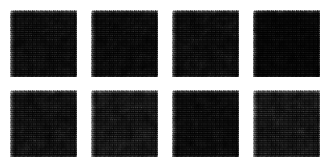

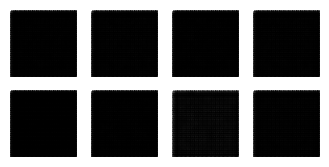

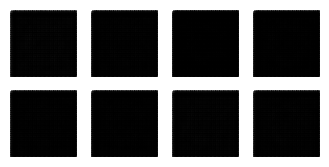

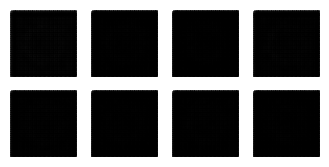

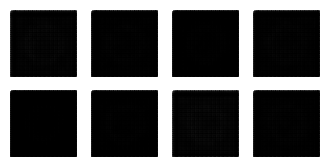

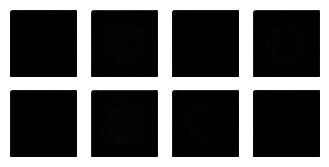

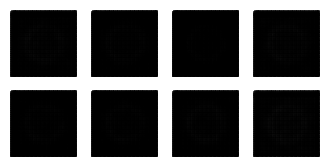

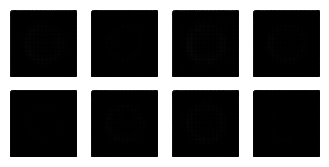

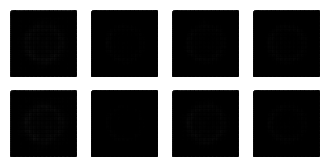

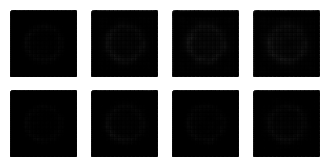

In [77]:
epochs = 10
latent_dim = 64 #for now
num_examples = 8

random_vector = tf.random.normal(shape=[num_examples, latent_dim])

model = ConVAE(latent_dim)

for epoch in range(1, epochs + 1):
    #training the values
    start_t = time.time()
    for train_im in train_dataset:
        training_vae(model, train_im, vae_optim)
    end_t = time.time()

    loss = tf.keras.metrics.Mean()
    #finding the loss to improve the next set of training
    for test_im in test_dataset:
        loss(loss_func(model, test_im))
    elbo = -loss.result()
    # clear_output(wait=False)
    print(f'Epoch: {epoch}, Test set ELBO: {elbo}, time elapse for current epoch: {end_t - start_t}')
    generating_images(model, epoch, test_sample)

    

In [87]:
def display_im(epoch_no):
    return PIL.Image.open('image_at_epoch_{:04d}.png'.format(epoch_no))

(np.float64(-0.5), np.float64(399.5), np.float64(399.5), np.float64(-0.5))

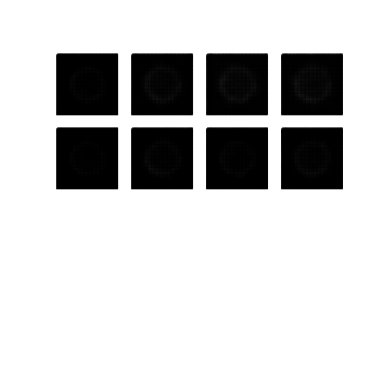

In [88]:
plt.imshow(display_im(epoch))
plt.axis('off')

In [78]:
z_train, _= model.encode(X_train)
z_test, _ = model.encode(X_test)

In [26]:
#checking shapes
print(X_train.shape) 
print(y_train_scaled.shape)
print(type(X_train))
print(type(y_train_scaled))
print(z_train.shape)
print(z_test.shape)

for target in targets:
    target = tf.cast(target, tf.float32)


(3779, 64, 64, 3)
(3779, 3)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(3779, 64)
(945, 64)


**Producing a predictor to obtain a predicted y from the latent space**

In [27]:
# predict = tf.keras.Sequential(
#         [tf.keras.layers.Input(shape=(latent_dim,)),
#          tf.keras.layers.Dense(128, activation = 'relu'),
#          tf.keras.layers.Dropout(0.3),
#          tf.keras.layers.Dense(3)]
# )
#obtain z from the vae to be used in the predictor training and train


# pred_optim = tf.keras.optimizers.Adam(learning_rate)



# @tf.function
# def training_predict(predict, z, target, pred_optim):
#     with tf.GradientTape() as tape:
#         prediction = predict(z)
#         pred_loss = tf.reduce_mean(tf.square(prediction-target))
#     pred_grad =tape.gradient(pred_loss, predict.trainable_variables )
#     pred_optim.apply_gradients(zip(pred_grad, predict.trainable_variables))
#     return pred_loss

In [28]:
print("Original target mean:")
print(y_train.mean(axis=0))

print("Original target std:")
print(y_train.std(axis=0))

print("\nScaled target mean:")
print(y_train_scaled.mean(axis=0))

print("Scaled target std:")
print(y_train_scaled.std(axis=0))

Original target mean:
[ 1.8564293  2.9337115 -8.166175 ]
Original target std:
[1.9719565 2.553843  1.8695076]

Scaled target mean:
[-8.8011092e-09 -5.8043157e-09 -2.4867077e-07]
Scaled target std:
[1.0000004  0.99999976 1.0000001 ]


In [29]:
prediction_data = tf.data.Dataset.from_tensor_slices((X_train, y_train_scaled))
prediction_data = prediction_data.batch(batch_size)

predictor = Sequential()

predictor.add(Input(shape=(latent_dim,)))

predictor.add(Dense(128, activation='relu'))

predictor.add(Dropout(0.3))

predictor.add(Dense(3))


In [30]:
predictor.summary()

predictor.compile(optimizer = 'adam', loss = 'mse', metrics = ['mae', 'accuracy'])

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,707 (34.01 KB)

 Trainable params: 8,707 (34.01 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history = predictor.fit(
    z_train,
    y_train_scaled,
    validation_split=0.2,
    epochs=10,
    batch_size=8,
    callbacks=[early_stop]
)

Epoch 1/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3248 - loss: 1.0382 - mae: 0.8507 - val_accuracy: 0.2526 - val_loss: 0.9745 - val_mae: 0.8289
Epoch 2/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 793us/step - accuracy: 0.3268 - loss: 1.0071 - mae: 0.8408 - val_accuracy: 0.2500 - val_loss: 0.9749 - val_mae: 0.8290
Epoch 3/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 804us/step - accuracy: 0.2544 - loss: 1.0068 - mae: 0.8407 - val_accuracy: 0.2500 - val_loss: 0.9748 - val_mae: 0.8290
Epoch 4/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 791us/step - accuracy: 0.2944 - loss: 1.0068 - mae: 0.8406 - val_accuracy: 0.2500 - val_loss: 0.9749 - val_mae: 0.8291
Epoch 5/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 787us/step - accuracy: 0.2557 - loss: 1.0066 - mae: 0.8406 - val_accuracy: 0.3704 - val_loss: 0.9746 - val_mae: 0.8288
Epoch 6/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - accuracy: 0.3192 - loss: 1.0067 - mae: 0.8406 - val_accuracy: 0.3704 - val_loss: 0.9747 - val_mae: 0.8289
Epoch 7/10
378/378 ━━━━━━━━━━━

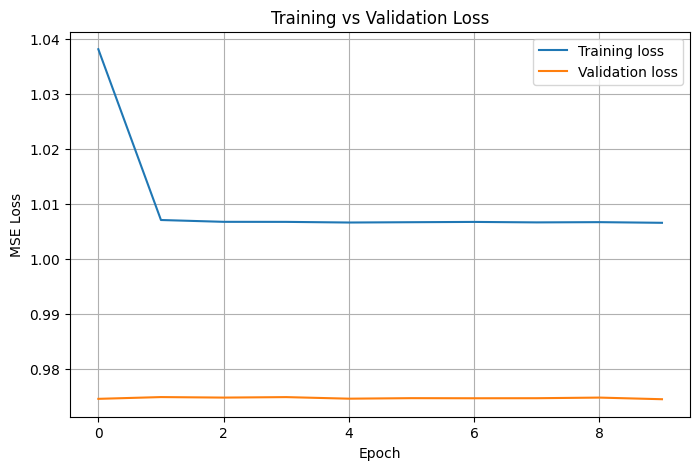

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()
     

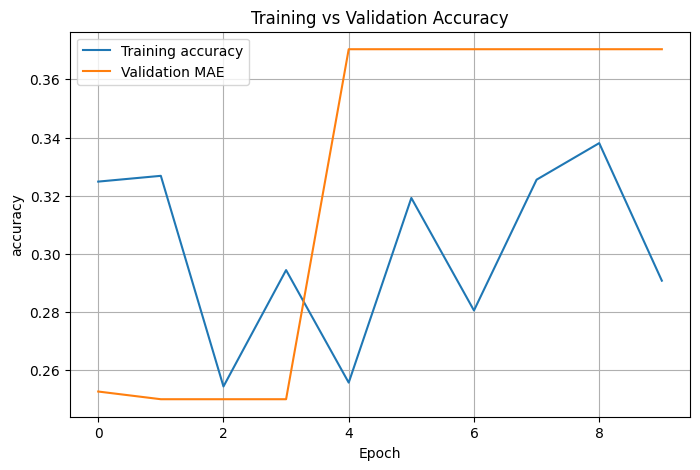

In [33]:

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

In [34]:
print("Target mean:", tf.reduce_mean(y_train_scaled, axis=0).numpy())
print("Target std:", tf.math.reduce_std(y_train_scaled, axis=0).numpy())

Target mean: [-8.8011092e-09 -5.8043157e-09 -2.4867077e-07]
Target std: [1.0000004  0.99999976 1.0000001 ]


In [35]:
print("Z shape:", z_test.shape)
print("Z std:", tf.math.reduce_std(z_test).numpy())

Z shape: (945, 64)
Z std: 0.7457699


In [36]:
model.summary()

model.compile(
    optimizer="adam",
    loss='mse',
    metrics=["mae", 'accuracy']
)

Model: "con_vae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128)            │     1,862,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 64, 64, 3)      │     1,121,219 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,983,939 (11.38 MB)

 Trainable params: 2,983,939 (11.38 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
test_loss, test_mae, test_accuracy = predictor.evaluate(z_test, y_test_scaled)

print(f'Test loss:{test_loss}')
print(f'Test MAE: {test_mae}')
print(f'Test accuracy: {test_accuracy}')

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - accuracy: 0.3481 - loss: 1.0479 - mae: 0.8731
Test loss:1.0478733777999878
Test MAE: 0.8731398582458496
Test accuracy: 0.3481481373310089


In [38]:
predictions = predictor.predict(z_test)

final_predict= target_scaler.inverse_transform(predictions)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [39]:
for i in range(5):
    print("True:     ", y_test[i])
    print("Predicted:", final_predict[i])
    print()

True:      [  3.9668674   -0.14068586 -11.376202  ]
Predicted: [ 1.8505129  2.9274487 -8.160869 ]

True:      [ 2.7431226  6.9315124 -7.3705173]
Predicted: [ 1.8505129  2.9274487 -8.160869 ]

True:      [ 0.01365993 -1.55306    -6.5534334 ]
Predicted: [ 1.8505129  2.9274487 -8.160869 ]

True:      [-1.0098882  0.9581149 -7.2366204]
Predicted: [ 1.8505129  2.9274487 -8.160869 ]

True:      [ 0.9073846  -0.41132656 -6.617211  ]
Predicted: [ 1.8505129  2.9274487 -8.160869 ]



In [40]:
position_error = final_predict[:,:3] - y_test_scaled[:,:3]


distance_error = np.sqrt(
    position_error[:,0]**2 +
    position_error[:,1]**2 +
    position_error[:,2]**2
)


print(
    "Mean annihilation position error:",
    np.mean(distance_error),
    "mm"
)

Mean annihilation position error: 8.954665 mm


**Test Accuracy, loss and MAE**

In [41]:
prediction_test = tf.data.Dataset.from_tensor_slices((X_test, y_test_scaled))
prediction_test = prediction_test.batch(batch_size)

predicts = []
targets = []

for image, target in prediction_test:
    mean, logvar = model.encode(image)

    z = mean

    prediction = image

    predicts.append(prediction)
    targets.append(target)


In [42]:
print(prediction[:5].numpy())
print(target[:5].numpy())

[[[[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  ...

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]

  [[0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]
   ...
   [0. 0. 0.]
   [0. 0. 0.]
   [0. 0. 0.]]]]
[[ 0.14106774 -0.71435475 -1.9215856 ]]


In [43]:
predicts = tf.concat(predicts, axis = 0)
targets = tf.concat(targets, axis=0)

print(predicts.shape)

print(targets.shape)

test_mse = tf.reduce_mean(
    tf.square(final_predict - target)
)

test_mae = tf.reduce_mean(
    tf.abs(final_predict - target)
)

print("VAE Test MSE:", test_mse.numpy())
print("VAE Test MAE:", test_mae.numpy())

predicts_scaled = final_predict
final_predict = target_scaler.inverse_transform(predicts_scaled)


(945, 64, 64, 3)
(945, 3)
VAE Test MSE: 18.371195
VAE Test MAE: 3.8635106


In [44]:
for i in range(5):
    print("True:     ", y_test[i])
    print("Predicted:", final_predict[i])
    print()


True:      [  3.9668674   -0.14068586 -11.376202  ]
Predicted: [  5.505562  10.409958 -23.422974]

True:      [ 2.7431226  6.9315124 -7.3705173]
Predicted: [  5.505562  10.409958 -23.422974]

True:      [ 0.01365993 -1.55306    -6.5534334 ]
Predicted: [  5.505562  10.409958 -23.422974]

True:      [-1.0098882  0.9581149 -7.2366204]
Predicted: [  5.505562  10.409958 -23.422974]

True:      [ 0.9073846  -0.41132656 -6.617211  ]
Predicted: [  5.505562  10.409958 -23.422974]



**Position Error**

In [45]:
position_error = final_predict[:,:3] - y_test[:,:3]


distance_error = np.sqrt(
    position_error[:,0]**2 +
    position_error[:,1]**2 +
    position_error[:,2]**2
)


print(
    "Mean annihilation position error:",
    np.mean(distance_error),
    "mm"
)

Mean annihilation position error: 17.618082 mm


** Reconstruction for X,Y,Z Annihilation - True vs Predicted **

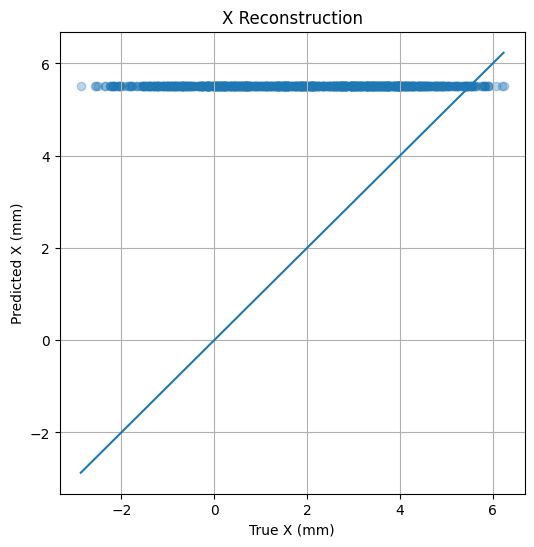

In [46]:
# X
plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,0],
    final_predict[:,0],
    alpha=0.3
)

plt.xlabel("True X (mm)")
plt.ylabel("Predicted X (mm)")
plt.title("X Reconstruction")

plt.plot(
    [y_test[:,0].min(), y_test[:,0].max()],
    [y_test[:,0].min(), y_test[:,0].max()]
)

plt.grid()
plt.show()

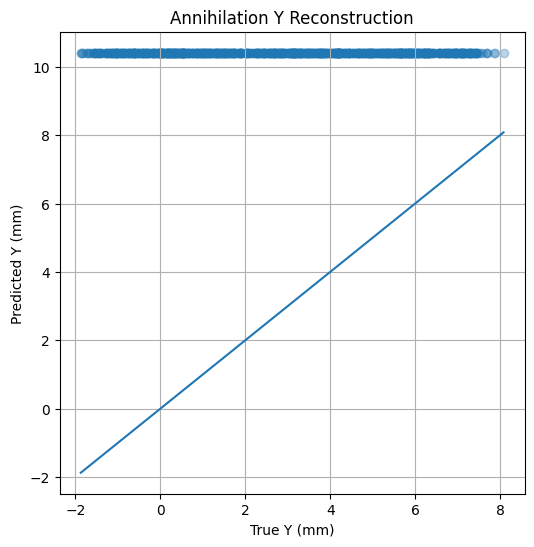

In [47]:
#Y
plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,1],          # True Y
   final_predict[:,1],      # Predicted Y
    alpha=0.3
)

plt.xlabel("True Y (mm)")
plt.ylabel("Predicted Y (mm)")

plt.title("Annihilation Y Reconstruction")


plt.plot(
    [y_test[:,1].min(), y_test[:,1].max()],
    [y_test[:,1].min(), y_test[:,1].max()]
)

plt.grid()
plt.show()

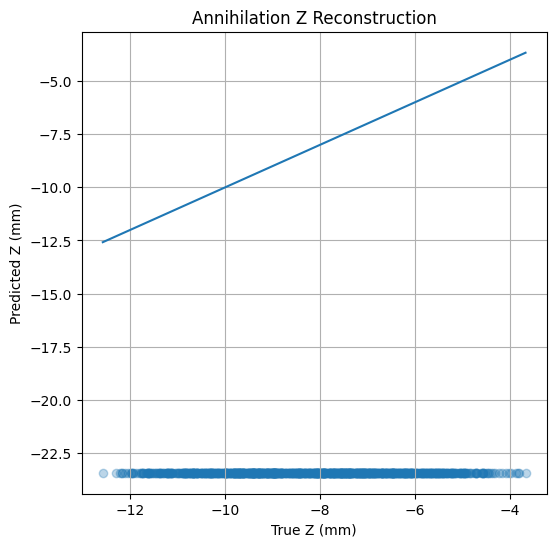

In [48]:
#Z
plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,2],          # True Z
    final_predict[:,2],      # Predicted Z
    alpha=0.3
)

plt.xlabel("True Z (mm)")
plt.ylabel("Predicted Z (mm)")

plt.title("Annihilation Z Reconstruction")


plt.plot(
    [y_test[:,2].min(), y_test[:,2].max()],
    [y_test[:,2].min(), y_test[:,2].max()]
)

plt.grid()
plt.show()

**Comparing to a baseline that is just guessing in the 'middle' position**

In [49]:
# comparing to baseline
mean_position = np.mean(y_train, axis=0)

print(mean_position)
baseline_prediction = np.tile(
    mean_position,
    (len(y_test),1)
)

from sklearn.metrics import mean_squared_error

baseline_mse = mean_squared_error(
    y_test,
    baseline_prediction
)

vae_mse = mean_squared_error(
    y_test,
    final_predict
)

print("Baseline MSE:", baseline_mse)
print("VAE+predictor MSE:", vae_mse)

[ 1.8564293  2.9337115 -8.166175 ]
Baseline MSE: 4.854374408721924
VAE+predictor MSE: 104.78231048583984


In [50]:
from sklearn.metrics import mean_absolute_error

baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

vae_mae = mean_absolute_error(
    y_test,
    final_predict
)

print("Baseline MAE:", baseline_mae)
print("vae+predictor MAE:", vae_mae)

Baseline MAE: 1.8638883829116821
vae+predictor MAE: 8.739350318908691


In [51]:
print("True X,Y,Z standard deviation:")
print(np.std(y_test, axis=0))

print("\nPredicted X,Y,Z standard deviation:")
print(np.std(final_predict, axis=0))

True X,Y,Z standard deviation:
[2.0363991 2.6074986 1.8983053]

Predicted X,Y,Z standard deviation:
[1.04904175e-05 1.02043152e-04 1.43051147e-04]


In [52]:
#comparing x,y,z separately
for i, coord in enumerate(["X","Y","Z"]):

    baseline = mean_absolute_error(
        y_test[:,i],
        baseline_prediction[:,i]
    )

    vae = mean_absolute_error(
        y_test[:,i],
        final_predict[:,i]
    )

    print(coord)
    print("Baseline:", baseline)
    print("VAE:", vae)
    print()

X
Baseline: 1.7378349304199219
VAE: 3.561216115951538

Y
Baseline: 2.256887674331665
VAE: 7.420878887176514

Z
Baseline: 1.5969411134719849
VAE: 15.23596477508545



In [53]:
from sklearn.metrics import r2_score

print("Overall R²:", r2_score(y_test, final_predict))

print("X R²:", r2_score(y_test[:,0], final_predict[:,0]))
print("Y R²:", r2_score(y_test[:,1], final_predict[:,1]))
print("Z R²:", r2_score(y_test[:,2], final_predict[:,2]))

Overall R²: -25.1848201751709
X R²: -3.036768913269043
Y R²: -8.099579811096191
Z R²: -64.4180908203125


**Plotting True and Predicted X,YZ co-ords**

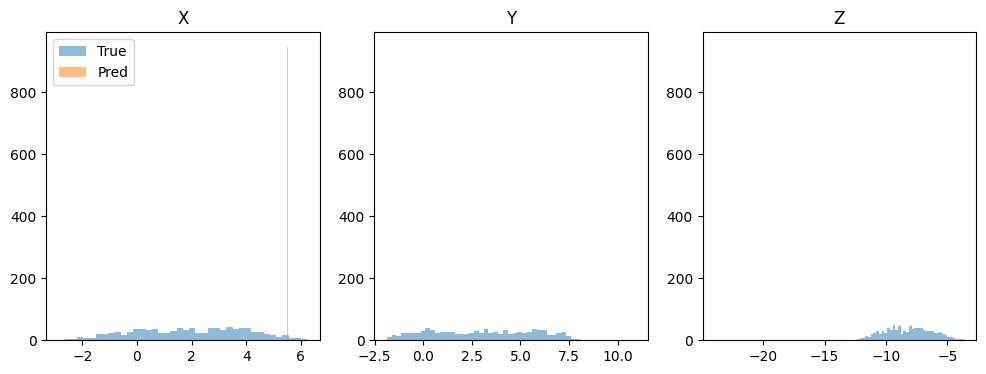

In [54]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(y_test[:,0], bins=40, alpha=0.5, label="True")
plt.hist(final_predict[:,0], bins=40, alpha=0.5, label="Pred")
plt.title("X")

plt.legend()

plt.subplot(1,3,2)
plt.hist(y_test[:,1], bins=40, alpha=0.5)
plt.hist(final_predict[:,1], bins=40, alpha=0.5)
plt.title("Y")

plt.subplot(1,3,3)
plt.hist(y_test[:,2], bins=40, alpha=0.5)
plt.hist(final_predict[:,2], bins=40, alpha=0.5)
plt.title("Z")

plt.show()

**Plotting Residuals - Difference between CNN model and True Annihilation Positions**

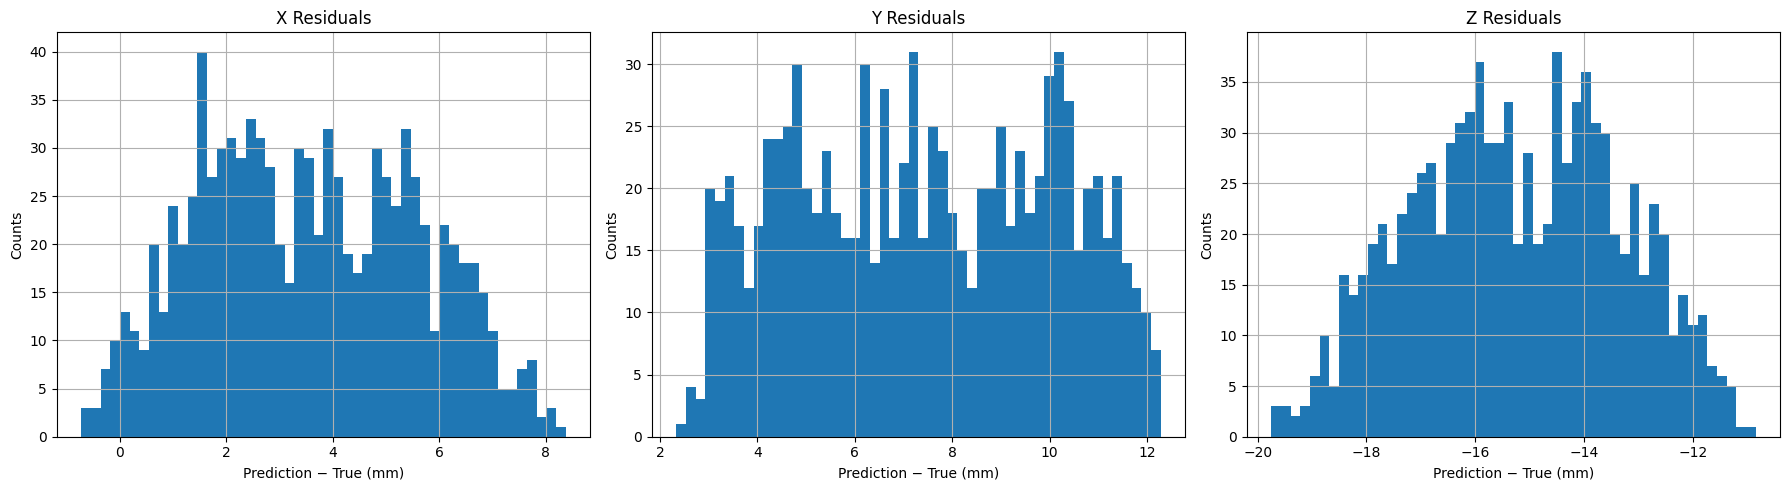

In [55]:
residuals = final_predict - y_test
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

coords = ["X", "Y", "Z"]

for i, ax in enumerate(axes):

    ax.hist(
        residuals[:, i],
        bins=50
    )

    ax.set_title(f"{coords[i]} Residuals")
    ax.set_xlabel("Prediction − True (mm)")
    ax.set_ylabel("Counts")
    ax.grid(True)

plt.tight_layout()
plt.show()


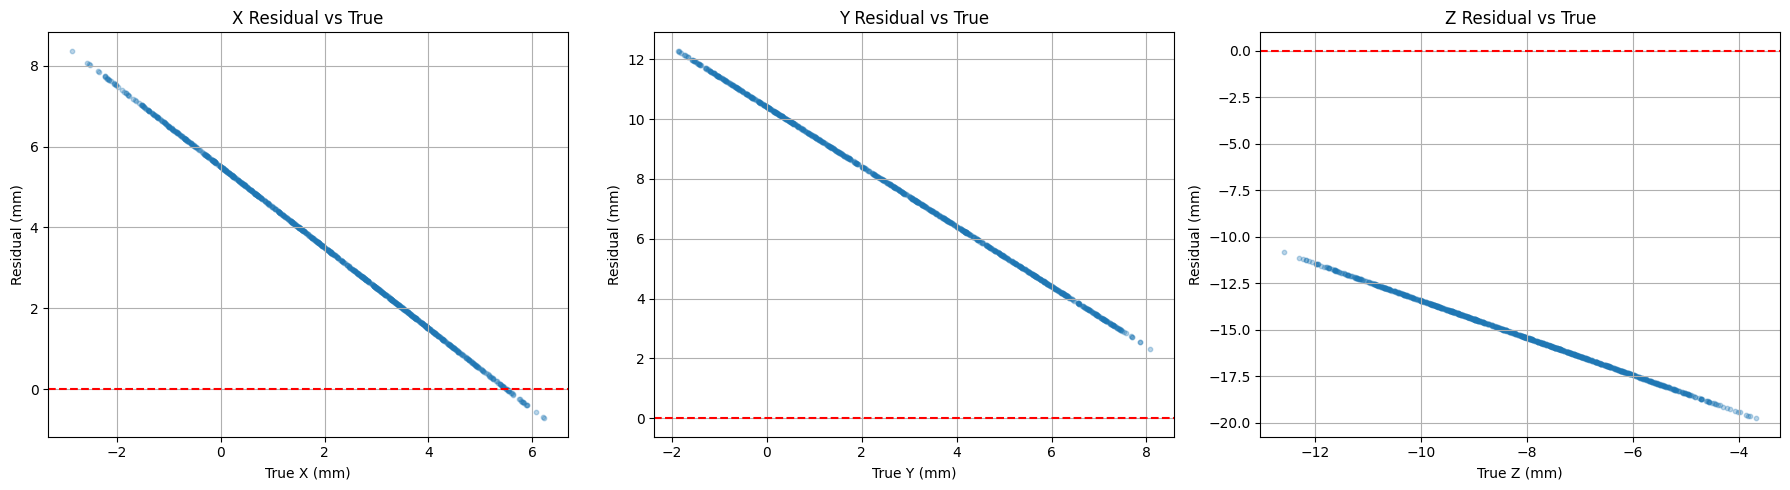

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

coords = ["X", "Y", "Z"]

for i, ax in enumerate(axes):

    ax.scatter(
        y_test[:, i],
        residuals[:, i],
        alpha=0.3,
        s=10
    )

    ax.axhline(
        0,
        color="red",
        linestyle="--"
    )

    ax.set_xlabel(f"True {coords[i]} (mm)")
    ax.set_ylabel("Residual (mm)")
    ax.set_title(f"{coords[i]} Residual vs True")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [57]:
coords = ["X", "Y", "Z"]

for i in range(3):

    print(f"{coords[i]}")

    print(f"Mean residual: {np.mean(residuals[:,i]):.2f} mm")
    print(f"Std residual : {np.std(residuals[:,i]):.2f} mm")
    print(f"MAE          : {np.mean(np.abs(residuals[:,i])):.2f} mm")

    print()

X
Mean residual: 3.55 mm
Std residual : 2.04 mm
MAE          : 3.56 mm

Y
Mean residual: 7.42 mm
Std residual : 2.61 mm
MAE          : 7.42 mm

Z
Mean residual: -15.24 mm
Std residual : 1.90 mm
MAE          : 15.24 mm

